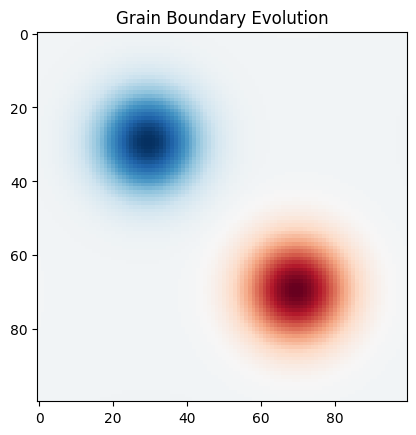

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
size = 100
dt = 0.1
L = 1.0  # Mobility
kappa = 2.0  # Gradient energy coefficient
steps = 500

# Initialize two grains (order parameters)
eta1 = np.random.rand(size, size) * 0.1
eta2 = np.random.rand(size, size) * 0.1

# Seed two grains
eta1[20:40, 20:40] = 1.0
eta2[60:80, 60:80] = 1.0

def laplacian(f):
    return (np.roll(f, 1, axis=0) + np.roll(f, -1, axis=0) +
            np.roll(f, 1, axis=1) + np.roll(f, -1, axis=1) - 4*f)

for _ in range(steps):
    # Free energy derivative w.r.t eta (simplified double-well)
    # This term forces eta to be 0 or 1
    df_deta1 = 2 * eta1 * (1 - eta1) * (1 - 2*eta1) + 2 * eta1 * eta2**2
    df_deta2 = 2 * eta2 * (1 - eta2) * (1 - 2*eta2) + 2 * eta2 * eta1**2
    
    # Allen-Cahn Update
    eta1 += dt * L * (kappa * laplacian(eta1) - df_deta1)
    eta2 += dt * L * (kappa * laplacian(eta2) - df_deta2)
    
    # Keep values bounded
    eta1 = np.clip(eta1, 0, 1)
    eta2 = np.clip(eta2, 0, 1)

# Simple visualization
plt.imshow(eta1 - eta2, cmap='RdBu')
plt.title("Grain Boundary Evolution")
plt.show()

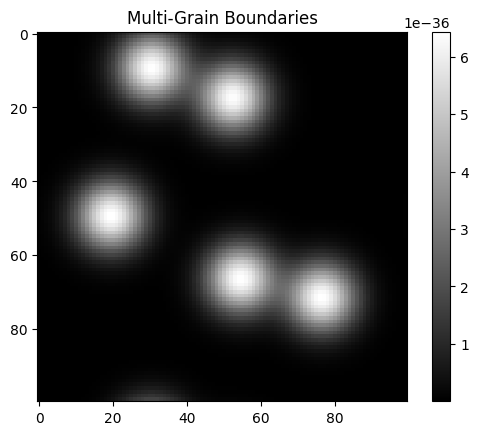

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
size = 100
num_grains = 5
dt = 0.05
L = 1.0
kappa = 2.0
a = 2.0     # Double well barrier height
gamma = 2.0 # Cross-penalty coefficient
steps = 500

# 1. Initialize 3D array: (grain_index, y, x)
eta = np.zeros((num_grains, size, size))

# Seed the grains randomly
for i in range(num_grains):
    y, x = np.random.randint(10, size-10, 2)
    eta[i, y-5:y+5, x-5:x+5] = 1.0

# Add a tiny bit of noise to help boundaries move
eta += np.random.rand(*eta.shape) * 0.01

def laplacian(f):
    return (np.roll(f, 1, axis=0) + np.roll(f, -1, axis=0) +
            np.roll(f, 1, axis=1) + np.roll(f, -1, axis=1) - 4*f)

for step in range(steps):
    # Calculate sum of eta_j^2 for the penalty term
    # sum_eta_sq shape: (size, size)
    sum_eta_sq = np.sum(eta**2, axis=0)
    
    for i in range(num_grains):
        # Subtract current grain's eta^2 to get sum_{j != i} eta_j^2
        other_eta_sq = sum_eta_sq - eta[i]**2
        
        # Derivative of local free energy
        df_deta = (a * eta[i] * (1 - eta[i]) * (1 - 2 * eta[i]) + 
                   2 * gamma * eta[i] * other_eta_sq)
        
        # Allen-Cahn Update
        eta[i] += dt * L * (kappa * laplacian(eta[i]) - df_deta)
    
    # Keep values bounded between 0 and 1
    eta = np.clip(eta, 0, 1)

# 3. Visualization: Sum of squares
# Inside a grain, sum(eta^2) ~ 1. At boundaries, it drops below 1.
boundaries = np.sum(eta**2, axis=0)

plt.imshow(boundaries, cmap='gray')
plt.title("Multi-Grain Boundaries")
plt.colorbar()
plt.show()

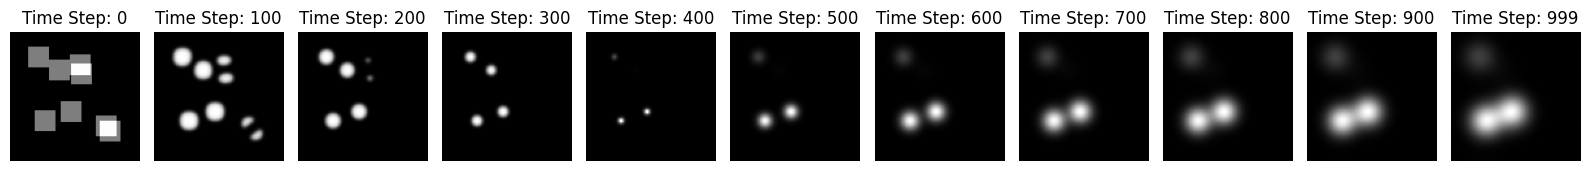

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
size = 100
num_grains = 8
dt = 0.05
L = 1.0
kappa = 2.0
a = 2.0     
gamma = 2.0 
steps = 1000

# Initialize
eta = np.zeros((num_grains, size, size))
for i in range(num_grains):
    y, x = np.random.randint(15, size-15, 2)
    # Start with slightly larger seed blocks
    eta[i, y-8:y+8, x-8:x+8] = 1.0 

eta += np.random.rand(*eta.shape) * 0.01

def laplacian_3d(f):
    return (np.roll(f, 1, axis=1) + np.roll(f, -1, axis=1) +
            np.roll(f, 1, axis=2) + np.roll(f, -1, axis=2) - 4*f)

# --- SETUP SNAPSHOTS ---
snapshots = []
capture_steps = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 999] # The time steps we want to photograph

# --- EVOLUTION LOOP ---
for step in range(steps):
    
    # 1. Capture the snapshot if it's the right time
    if step in capture_steps:
        boundaries = np.sum(eta**2, axis=0)
        snapshots.append(boundaries)

    # 2. Calculate Physics
    sum_eta_sq = np.sum(eta**2, axis=0, keepdims=True) 
    other_eta_sq = sum_eta_sq - eta**2
    df_deta = (a * eta * (1 - eta) * (1 - 2 * eta) + 2 * gamma * eta * other_eta_sq)
    
    # 3. Step forward in time
    eta += dt * L * (kappa * laplacian_3d(eta) - df_deta)
    eta = np.clip(eta, 0, 1)


# --- PLOT THE TIME-LAPSE ---
fig, axes = plt.subplots(1, len(capture_steps), figsize=(16, 4))

for i, (ax, img, step) in enumerate(zip(axes, snapshots, capture_steps)):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Time Step: {step}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. THERMODYNAMIC PARAMETERS
# ==========================================
T = 650          # Current Temperature (K)
T_m = 1000       # Melting Temperature (K)
dH = 1e9         # Latent heat of fusion (J/m^3)
gamma_surf = 0.2 # Surface energy (J/m^2)
Qd = 1e5         # Activation energy for diffusion (J/mol)
R = 8.314        # Gas constant

# Calculate Thermodynamic Rates
# 1. Driving Force (Volumetric Free Energy Change)
dGv = dH * (T_m - T) / T_m
scaled_dGv = (dGv/dH)*40


print(f"Thermodynamic Driving Force (Scaled): {scaled_dGv:.2f}")
# 2. Nucleation Barrier
dG_star = (16 * np.pi * gamma_surf**3) / (3 * dGv**2)

# 3. Relative Nucleation Rate & Growth Rate
# (Scaled down artificially so they play nicely with phase-field time steps)
I_rate = np.exp(-dG_star / (R * T)) * np.exp(-Qd / (R * T))
v_rate = (1 - np.exp(-dGv / (R * T))) * np.exp(-Qd / (R * T))

# Map to Phase-Field Variables
nucleation_prob = I_rate * 1e12  # Scaled probability of a seed forming per step
L = v_rate * 1e7                 # Scaled Phase-field mobility

print(f"Temperature: {T}K | Mobility (L): {L:.3f} | Nucleation Prob: {nucleation_prob:.4f}")

# ==========================================
# 2. PHASE-FIELD PARAMETERS
# ==========================================
size = 150             # Grid size (150x150)
max_grains = 25        # Maximum number of grains that can nucleate
dt = 0.02              # Time step
kappa = 1.0            # Gradient energy (Low = sharper boundaries)
a = 2.0                # Double-well barrier (High = strict 0 or 1 values)
gamma_pen = 4.0        # Cross-penalty (High = prevents overlapping)
steps = 800            # Total simulation steps

# Initialize empty 3D array: (grain_index, y, x)
eta = np.zeros((max_grains, size, size))
active_grains = 0      # Keep track of how many grains have nucleated

# Vectorized 9-Point Isotropic 3D Laplacian
def laplacian_3d(f):
    # Orthogonal neighbors (Up, Down, Left, Right)
    ortho = (np.roll(f, 1, axis=1) + np.roll(f, -1, axis=1) +
             np.roll(f, 1, axis=2) + np.roll(f, -1, axis=2))
    
    # Diagonal neighbors (The 4 corners)
    diag = (np.roll(np.roll(f, 1, axis=1), 1, axis=2) + 
            np.roll(np.roll(f, 1, axis=1), -1, axis=2) +
            np.roll(np.roll(f, -1, axis=1), 1, axis=2) + 
            np.roll(np.roll(f, -1, axis=1), -1, axis=2))
    
    # Isotropic weights: 2/3 for ortho, 1/6 for diag, -10/3 for center
    return (2.0/3.0) * ortho + (1.0/6.0) * diag - (10.0/3.0) * f

# ==========================================
# 3. MAIN SIMULATION LOOP
# ==========================================
snapshots = []
capture_steps = [50, 200, 400, 600, 799]

for step in range(steps):
    
    # --- A. CONTINUOUS NUCLEATION ---
    if active_grains < max_grains and np.random.rand() < nucleation_prob:
        # Pick a random location away from the edges
        y, x = np.random.randint(15, size-15, 2)
        
        # Check if the space is currently empty
        if np.sum(eta[:, y, x]**2) < 0.1:
            
            # NEW: Randomly sample a seed radius between 2 and 8
            # This creates seed blocks ranging from 4x4 to 16x16
            r = np.random.randint(2, 9) 
            
            eta[active_grains, y-r:y+r, x-r:x+r] = 1.0
            active_grains += 1

    # --- B. PHASE-FIELD EVOLUTION (KINETICS) ---
    # Calculate sum of squares for penalty term
    sum_eta_sq = cp.sum(eta**2, axis=0, keepdims=True) 
    other_eta_sq = sum_eta_sq - eta**2
    
    tilt = scaled_dGv * 30 * (eta**2) * ((1 - eta)**2) * liquid

    # Local free energy derivative
    df_deta = (a * eta * (1 - eta) * (1 - 2 * eta) + 
               2 * gamma_pen * eta * other_eta_sq) - tilt
    # Allen-Cahn update using thermodynamically-derived Mobility (L)
    eta += dt * L * (kappa * laplacian_3d(eta) - df_deta)
    
    # Keep values bounded between 0 and 1
    eta = np.clip(eta, 0, 1)

    # --- C. CAPTURE SNAPSHOTS ---
    if step in capture_steps:
        # np.argmax assigns an integer to each pixel based on the dominant grain
        # We add a small noise matrix so empty space doesn't default to color 0
        noise = np.random.rand(size, size) * 0.001
        dominant_grain = np.argmax(eta + noise, axis=0)
        
        # Mask out the empty space (where no grain has grown yet)
        empty_space_mask = np.sum(eta, axis=0) < 0.1
        dominant_grain = np.where(empty_space_mask, -1, dominant_grain)
        
        snapshots.append(dominant_grain)

# ==========================================
# 4. VISUALIZATION
# ==========================================
fig, axes = plt.subplots(1, len(capture_steps), figsize=(18, 5))

# Create a custom colormap that makes empty space (-1) black
cmap = plt.cm.get_cmap('tab20', max_grains)
cmap.set_under('black')

for ax, img, step in zip(axes, snapshots, capture_steps):
    # vmin=-0.5 ensures that the -1 empty space is treated as 'under' and colored black
    im = ax.imshow(img, cmap=cmap, vmin=-0.5, vmax=max_grains)
    ax.set_title(f"Time Step: {step}")
    ax.axis('off')

plt.suptitle(f"Microstructure Evolution at T = {T}K", fontsize=16)
plt.tight_layout()
plt.show()

Thermodynamic Driving Force (Scaled): 14.00
Temperature: 650K | Mobility (L): 0.092 | Nucleation Prob: 9196.2612


TypeError: Unsupported type <class 'numpy.ndarray'>

In [3]:
pip install cupy-cuda12x

   ---------------------------------------- 0.0/96.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/96.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/96.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/96.3 MB 330.3 kB/s eta 0:04:52
   ---------------------------------------- 0.2/96.3 MB 1.6 MB/s eta 0:01:01
   ---------------------------------------- 0.6/96.3 MB 3.5 MB/s eta 0:00:27
   ---------------------------------------- 0.9/96.3 MB 4.5 MB/s eta 0:00:22
   ---------------------------------------- 1.0/96.3 MB 4.4 MB/s eta 0:00:22
   ---------------------------------------- 1.0/96.3 MB 4.4 MB/s eta 0:00:22
   ---------------------------------------- 1.0/96.3 MB 4.4 MB/s eta 0:00:22
   ---------------------------------------- 1.0/96.3 MB 4.4 MB/s eta 0:00:22
    --------------------------------------- 1.5/96.3 MB 3.3 MB/s eta 0:00:29
    --------------------------------------- 1.6/96.3 MB 3.4 MB/s eta 0:00:28
    --------------


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install cupy-cuda13x

   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/35.4 MB ? eta -:--:--
   -----------------


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Thermodynamic Driving Force (Scaled): 10.00
Temperature: 750K | Mobility (L): 1.084 | Nucleation Prob: 108425.0898


C:\Users\HP\AppData\Local\Temp\ipykernel_5128\1949553658.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max_grains)


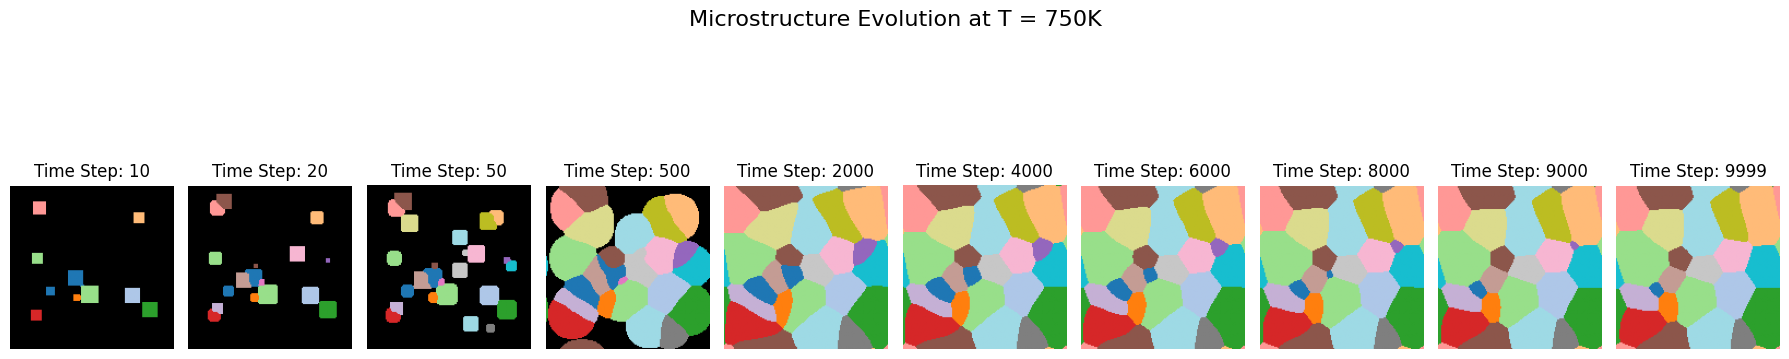

In [7]:
import cupy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. THERMODYNAMIC PARAMETERS
# ==========================================
T = 750          # Current Temperature (K)
T_m = 1000       # Melting Temperature (K)
dH = 1e9         # Latent heat of fusion (J/m^3)
gamma_surf = 0.2 # Surface energy (J/m^2)
Qd = 1e5         # Activation energy for diffusion (J/mol)
R = 8.314        # Gas constant

# Calculate Thermodynamic Rates
# 1. Driving Force (Volumetric Free Energy Change)
dGv = dH * (T_m - T) / T_m
scaled_dGv = (dGv/dH)*40


print(f"Thermodynamic Driving Force (Scaled): {scaled_dGv:.2f}")
# 2. Nucleation Barrier
dG_star = (16 * np.pi * gamma_surf**3) / (3 * dGv**2)

# 3. Relative Nucleation Rate & Growth Rate
# (Scaled down artificially so they play nicely with phase-field time steps)
I_rate = np.exp(-dG_star / (R * T)) * np.exp(-Qd / (R * T))
v_rate = (1 - np.exp(-dGv / (R * T))) * np.exp(-Qd / (R * T))

# Map to Phase-Field Variables
nucleation_prob = I_rate * 1e12  # Scaled probability of a seed forming per step
L = v_rate * 1e7                 # Scaled Phase-field mobility

print(f"Temperature: {T}K | Mobility (L): {L:.3f} | Nucleation Prob: {nucleation_prob:.4f}")

# ==========================================
# 2. PHASE-FIELD PARAMETERS
# ==========================================
size = 150             # Grid size (150x150)
max_grains = 25        # Maximum number of grains that can nucleate
dt = 0.002              # Time step
kappa = 4.0            # Gradient energy (Low = sharper boundaries)
a = 0.5                # Double-well barrier (High = strict 0 or 1 values)
gamma_pen = 1.5      # Cross-penalty (High = prevents overlapping)
steps = 10000      # Total simulation steps

# Initialize empty 3D array: (grain_index, y, x)
eta = np.zeros((max_grains, size, size))
active_grains = 0      # Keep track of how many grains have nucleated

# Vectorized 9-Point Isotropic 3D Laplacian
def laplacian_3d(f):
    # Orthogonal neighbors (Up, Down, Left, Right)
    ortho = (np.roll(f, 1, axis=1) + np.roll(f, -1, axis=1) +
             np.roll(f, 1, axis=2) + np.roll(f, -1, axis=2))
    
    # Diagonal neighbors (The 4 corners)
    diag = (np.roll(np.roll(f, 1, axis=1), 1, axis=2) + 
            np.roll(np.roll(f, 1, axis=1), -1, axis=2) +
            np.roll(np.roll(f, -1, axis=1), 1, axis=2) + 
            np.roll(np.roll(f, -1, axis=1), -1, axis=2))
    
    # Isotropic weights: 2/3 for ortho, 1/6 for diag, -10/3 for center
    return (2.0/3.0) * ortho + (1.0/6.0) * diag - (10.0/3.0) * f

# ==========================================
# 3. MAIN SIMULATION LOOP
# ==========================================
snapshots = []
capture_steps = [10, 20, 50, 500, 2000, 4000, 6000, 8000, 9000, 9999]

for step in range(steps):
    
    # --- A. CONTINUOUS NUCLEATION ---
    if active_grains < max_grains and np.random.rand() < nucleation_prob:
        # Pick a random location away from the edges
        y, x = np.random.randint(15, size-15, 2)
        
        # Check if the space is currently empty
        if np.sum(eta[:, y, x]**2) < 0.1:
            
            # NEW: Randomly sample a seed radius between 2 and 8
            # This creates seed blocks ranging from 4x4 to 16x16
            r = np.random.randint(2, 9) 
            
            eta[active_grains, y-r:y+r, x-r:x+r] = 1.0
            active_grains += 1

    # --- B. PHASE-FIELD EVOLUTION (KINETICS) ---
    # Calculate sum of squares for penalty term
    sum_eta_sq = np.sum(eta**2, axis=0, keepdims=True) 
    other_eta_sq = sum_eta_sq - eta**2

    liquid = 1.0 - np.sum(eta, axis=0, keepdims=True)
    liquid = np.clip(liquid, 0.0, 1.0)
    
    tilt = scaled_dGv * 30 * (eta**2) * ((1 - eta)**2) * liquid

    # Local free energy derivative
    df_deta = (a * eta * (1 - eta) * (1 - 2 * eta) + 
               2 * gamma_pen * eta * other_eta_sq) - tilt
    # Allen-Cahn update using thermodynamically-derived Mobility (L)

    if np.mean(liquid) < 0.05:
        current_L = 2.5  # Coarsening Phase (Fast-forward)
    else:
        current_L = L

    eta += dt * current_L * (kappa * laplacian_3d(eta) - df_deta)
    
    # Keep values bounded between 0 and 1
    eta = np.clip(eta, 0, 1)

    # --- C. CAPTURE SNAPSHOTS ---
    if step in capture_steps:
        # np.argmax assigns an integer to each pixel based on the dominant grain
        # We add a small noise matrix so empty space doesn't default to color 0
        noise = np.random.rand(size, size) * 0.001
        dominant_grain = np.argmax(eta + noise, axis=0)
        
        # Mask out the empty space (where no grain has grown yet)
        empty_space_mask = np.sum(eta, axis=0) < 0.1
        dominant_grain = np.where(empty_space_mask, -1, dominant_grain)
        
        snapshots.append(dominant_grain)

# ==========================================
# 4. VISUALIZATION
# ==========================================
fig, axes = plt.subplots(1, len(capture_steps), figsize=(18, 5))

# Create a custom colormap that makes empty space (-1) black
cmap = plt.cm.get_cmap('tab20', max_grains)
cmap.set_under('black')

for ax, img, step in zip(axes, snapshots, capture_steps):
    # vmin=-0.5 ensures that the -1 empty space is treated as 'under' and colored black
    im = ax.imshow(img.get(), cmap=cmap, vmin=-0.5, vmax=max_grains)
    ax.set_title(f"Time Step: {step}")
    ax.axis('off')

plt.suptitle(f"Microstructure Evolution at T = {T}K", fontsize=16)
plt.tight_layout()
plt.show()

In [3]:
# Uncomment the line below if running inside a Jupyter Notebook:
%matplotlib qt 

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Slider
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. CONSTANTS & PARAMETERS
# ==========================================
T_m = 1000       
dH = 1e9         
gamma_surf = 0.2 
Qd = 1e5         
R = 8.314        

# Increased scale to show off GPU performance
size = 250             
max_grains = 40        
dt = 0.002             

# The "Golden Parameters" for stable coarsening
kappa = 4.0            
a = 0.5                
gamma_pen = 1.5        

# Initialize Grid directly on the GPU
eta = cp.zeros((max_grains, size, size), dtype=cp.float32)
active_grains = 0

# 9-Point Isotropic Laplacian (Fully GPU Accelerated)
def laplacian_3d(f):
    ortho = (cp.roll(f, 1, axis=1) + cp.roll(f, -1, axis=1) +
             cp.roll(f, 1, axis=2) + cp.roll(f, -1, axis=2))
    
    diag = (cp.roll(cp.roll(f, 1, axis=1), 1, axis=2) + 
            cp.roll(cp.roll(f, 1, axis=1), -1, axis=2) +
            cp.roll(cp.roll(f, -1, axis=1), 1, axis=2) + 
            cp.roll(cp.roll(f, -1, axis=1), -1, axis=2))
    
    return (2.0/3.0) * ortho + (1.0/6.0) * diag - (10.0/3.0) * f

# ==========================================
# 2. UI AND PLOT SETUP (Runs on CPU)
# ==========================================
fig, ax = plt.subplots(figsize=(8, 8))
plt.subplots_adjust(bottom=0.25) 

cmap = plt.cm.get_cmap('tab20', max_grains)
cmap.set_under('black')

# Create initial empty image using standard NumPy
im = ax.imshow(np.full((size, size), -1), cmap=cmap, vmin=-0.5, vmax=max_grains)
ax.axis('off')
title = ax.set_title("Initializing GPU...")

# Create the Temperature Slider
ax_temp = plt.axes([0.15, 0.1, 0.65, 0.03])
temp_slider = Slider(ax=ax_temp, label='Temp (K)', valmin=500, valmax=990, valinit=850)

# ==========================================
# 3. LIVE ANIMATION LOOP
# ==========================================
def update(frame):
    global eta, active_grains
    
    # Read slider (CPU side)
    T = temp_slider.val
    
    # Calculate Thermodynamics
    dGv = max(dH * (T_m - T) / T_m, 1.0) 
    scaled_dGv = (dGv / dH) * 40.0
    
    dG_star = (16 * np.pi * gamma_surf**3) / (3 * dGv**2)
    I_rate = np.exp(-dG_star / (R * T)) * np.exp(-Qd / (R * T))
    v_rate = (1 - np.exp(-dGv / (R * T))) * np.exp(-Qd / (R * T))
    
    nucleation_prob = I_rate * 1e12
    L = v_rate * 1e7

    # Run multiple physics steps per UI frame to utilize GPU speed
    steps_per_frame = 5 
    
    for _ in range(steps_per_frame):
        # A. Nucleation
        # We use np.random here to avoid unnecessary GPU synchronization overhead
        if active_grains < max_grains and np.random.rand() < nucleation_prob:
            y, x = np.random.randint(15, size-15, 2)
            
            # Pull a single pixel back to CPU to check if it's empty
            if float(cp.sum(eta[:, y, x]**2)) < 0.1:
                r = np.random.randint(2, 9)
                # Plant the seed on the GPU
                eta[active_grains, y-r:y+r, x-r:x+r] = 1.0
                active_grains += 1

        # B. Kinetics & Thermodynamics (Pure GPU Math)
        sum_eta_sq = cp.sum(eta**2, axis=0, keepdims=True) 
        other_eta_sq = sum_eta_sq - eta**2
        
        liquid = 1.0 - cp.sum(eta, axis=0, keepdims=True)
        liquid = cp.clip(liquid, 0.0, 1.0)
        
        tilt = scaled_dGv * 30 * (eta**2) * ((1 - eta)**2) * liquid
        
        df_deta = (a * eta * (1 - eta) * (1 - 2 * eta) + 
                   2 * gamma_pen * eta * other_eta_sq) - tilt
        
        # Coarsening Time Warp / Speed Limit
        if cp.mean(liquid) < 0.05:
            current_L = 2.5  
        else:
            current_L = L          
            
        # Allen-Cahn Update
        eta += dt * current_L * (kappa * laplacian_3d(eta) - df_deta)
        eta = cp.clip(eta, 0, 1)

    # C. Flatten matrix and transfer to CPU for Matplotlib
    noise = cp.random.rand(size, size) * 0.001
    dominant_grain = cp.argmax(eta + noise, axis=0)
    empty_space_mask = cp.sum(eta, axis=0) < 0.1
    dominant_grain = cp.where(empty_space_mask, -1, dominant_grain)
    
    # **CRITICAL BRIDGE:** Pull the final 2D array from VRAM to System RAM
    render_grid = cp.asnumpy(dominant_grain)
    
    im.set_data(render_grid)
    title.set_text(f"T = {T:.0f}K | L = {L:.2f} | Nuc Prob = {nucleation_prob:.1f}")
    
    return [im, title]

# Start the live animation

ani = FuncAnimation(fig, update, frames=2000, interval=20, blit=True)
plt.show()

In [9]:
pip install PyQt6

   ---------------------------------------- 0.0/6.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.8 MB 145.2 kB/s eta 0:00:47
   ---------------------------------------- 0.1/6.8 MB 252.2 kB/s eta 0:00:27
   - -------------------------------------- 0.2/6.8 MB 737.3 kB/s eta 0:00:10
   - -------------------------------------- 0.3/6.8 MB 999.9 kB/s eta 0:00:07
   -- ------------------------------------- 0.4/6.8 MB 1.1 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/6.8 MB 1.2 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/6.8 M


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
